In [54]:
# All imports
import pandas as pd
from Classes import FileManager as fm
from Classes.DataPlotter import DataPlotter
from Classes import Calculations as calc

# Folder with run data (e.g., SD card)
folder = r"Data"

# Get latest CSV file
latest_file = fm.get_latest_file(folder)
print(latest_file)

# Create plotter object for graphs
# plotter = DataPlotter(r"D:\d_71.csv")
plotter = DataPlotter(latest_file)

# plotter = DataPlotter(CSV_PATH)
plotter.load_data()

#Track Len
TRACK_LEN = 3832.5


Data/d_73.csv


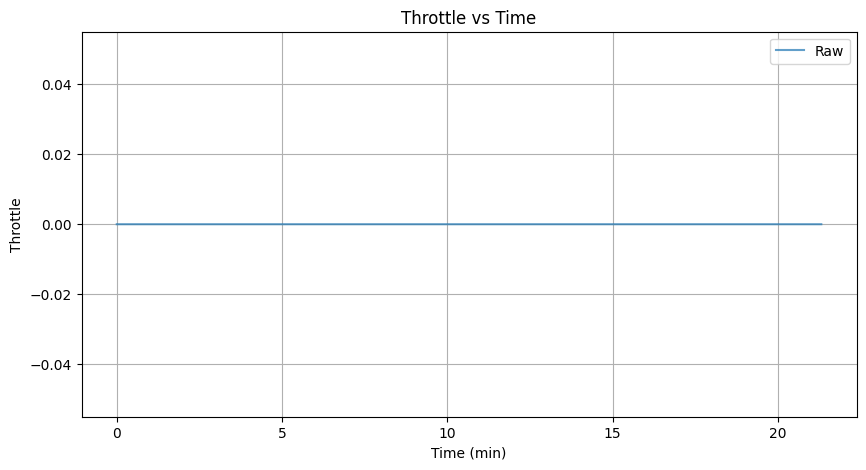

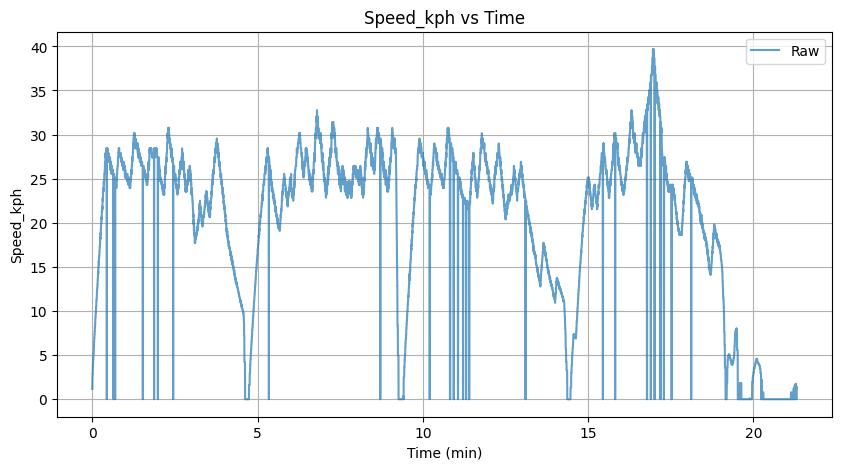

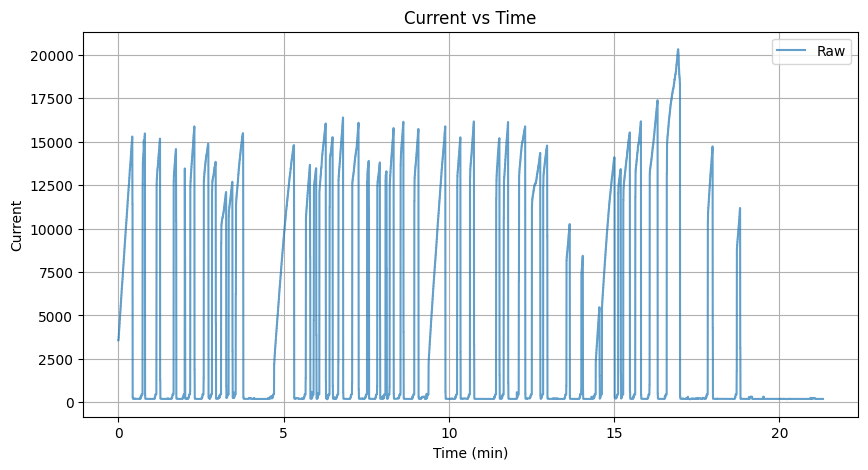

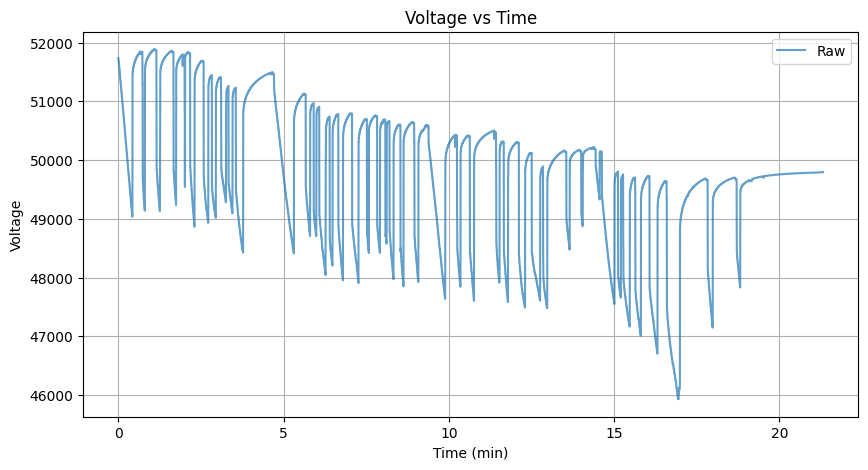

In [55]:
# Plot all columns
plotter.plot_all(smooth_window=0)

In [56]:
calc.get_efficiency(num_laps=2,energy_joules=267_844,track_len_km=TRACK_LEN)

Efficiency: 103022.65 km/kWh


In [57]:
calc.get_total_energy(plotter.data)


Total energy consumed: 269000.9401171078 J or 0.07472248336586329 kWh


# Track Map — IMS Grand Prix Road Course
Mapping **voltage**, **current draw**, and **car speed** onto the track layout.

| Parameter | Value |
|-----------|-------|
| Wheel diameter | 0.55 m |
| Encoder ticks/rev | 4 |
| Distance per tick | π × 0.55 / 4 ≈ 0.432 m |
| Track length | 3.875 km (15.5 / 4) |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# ── Physical parameters ──
WHEEL_DIAM = 0.55  # m
N_ENC = 4
CIRCUMFERENCE = np.pi * WHEEL_DIAM          # 1.7279 m
DIST_PER_TICK = CIRCUMFERENCE / N_ENC       # 0.4320 m
TRACK_LEN = 3832.5                          # metres (15.5/4 km)
SPEED_SCALE = 1.0  # scaling factor applied to raw speed (tune to match known lap distance)
CHOP_SECONDS = 0   # drop the first N seconds of data (e.g. pre-start idle)

# ── Process telemetry ──
df = plotter.data.copy()

# Chop leading data
if CHOP_SECONDS > 0:
    chop_ms = CHOP_SECONDS * 1000
    df = df[df['Tick'] >= chop_ms].copy()
    df['Tick'] = df['Tick'] - df['Tick'].iloc[0]   # re-zero after chop
    df['TimePlot'] = df['Tick'] / 60_000            # recalc minutes

# Recompute speed with scaling factor (raw Speed * 0.001 = kph before scaling)
df['Speed_kph'] = df['Speed'] * 0.001 * SPEED_SCALE
df['Speed_mps'] = df['Speed_kph'] / 3.6
df['Voltage_V'] = df['Voltage'] / 1000.0    # mV -> V
df['Current_A'] = df['Current'] / 1000.0    # mA -> A
df['dt'] = df['Tick'].diff().fillna(0) / 1000.0   # ms -> s
df['Distance_m'] = np.cumsum(df['Speed_mps'].values * df['dt'].values)
df['TrackPos'] = df['Distance_m'] % TRACK_LEN

total_dist = df['Distance_m'].iloc[-1]
n_laps = total_dist / TRACK_LEN
print(f"Wheel dia: {WHEEL_DIAM} m | Circumference: {CIRCUMFERENCE:.4f} m")
print(f"Encoder ticks/rev: {N_ENC} | Distance/tick: {DIST_PER_TICK:.4f} m")
print(f"Speed scale: {SPEED_SCALE}")
if CHOP_SECONDS > 0:
    print(f"Chopped first {CHOP_SECONDS}s — {len(plotter.data) - len(df)} samples removed")
print(f"Total distance: {total_dist:.0f} m ({total_dist/1000:.2f} km)")
print(f"Laps completed: {n_laps:.2f}")
print(f"Max speed: {df['Speed_kph'].max():.1f} kph | "
      f"Avg moving speed: {df.loc[df['Speed_kph'] > 1, 'Speed_kph'].mean():.1f} kph")
print(f"Voltage: {df['Voltage_V'].min():.1f} - {df['Voltage_V'].max():.1f} V | "
      f"Current: {df['Current_A'].min():.1f} - {df['Current_A'].max():.1f} A")

# ── Load real GPS track centreline ──
track_gps = pd.read_csv('sem-us-2022-track_coordinates.csv')
gps_lat = track_gps.Latitude.values
gps_lon = track_gps.Longitude.values

# Convert GPS -> local XY (metres)
lat_ref = gps_lat.mean()
lon_ref = gps_lon.mean()
m_per_deg_lat = 110_540
m_per_deg_lon = 111_320 * np.cos(np.radians(lat_ref))
track_x = (gps_lon - lon_ref) * m_per_deg_lon
track_y = (gps_lat - lat_ref) * m_per_deg_lat
track_xy = np.column_stack([track_x, track_y])

# Arc-length along the GPS centreline
seg_lens = np.sqrt(np.sum(np.diff(track_xy, axis=0)**2, axis=1))
arc = np.zeros(len(track_xy))
arc[1:] = np.cumsum(seg_lens)
total_arc = arc[-1]

def dist_to_xy(d):
    """Map a track distance (m) to an (x, y) point on the GPS centreline."""
    arc_pos = (d / TRACK_LEN) * total_arc
    idx = min(np.searchsorted(arc, arc_pos % total_arc), len(track_xy) - 1)
    return track_xy[idx]

print(f"\nGPS track: {len(track_xy)} pts | arc = {total_arc:.0f} m")

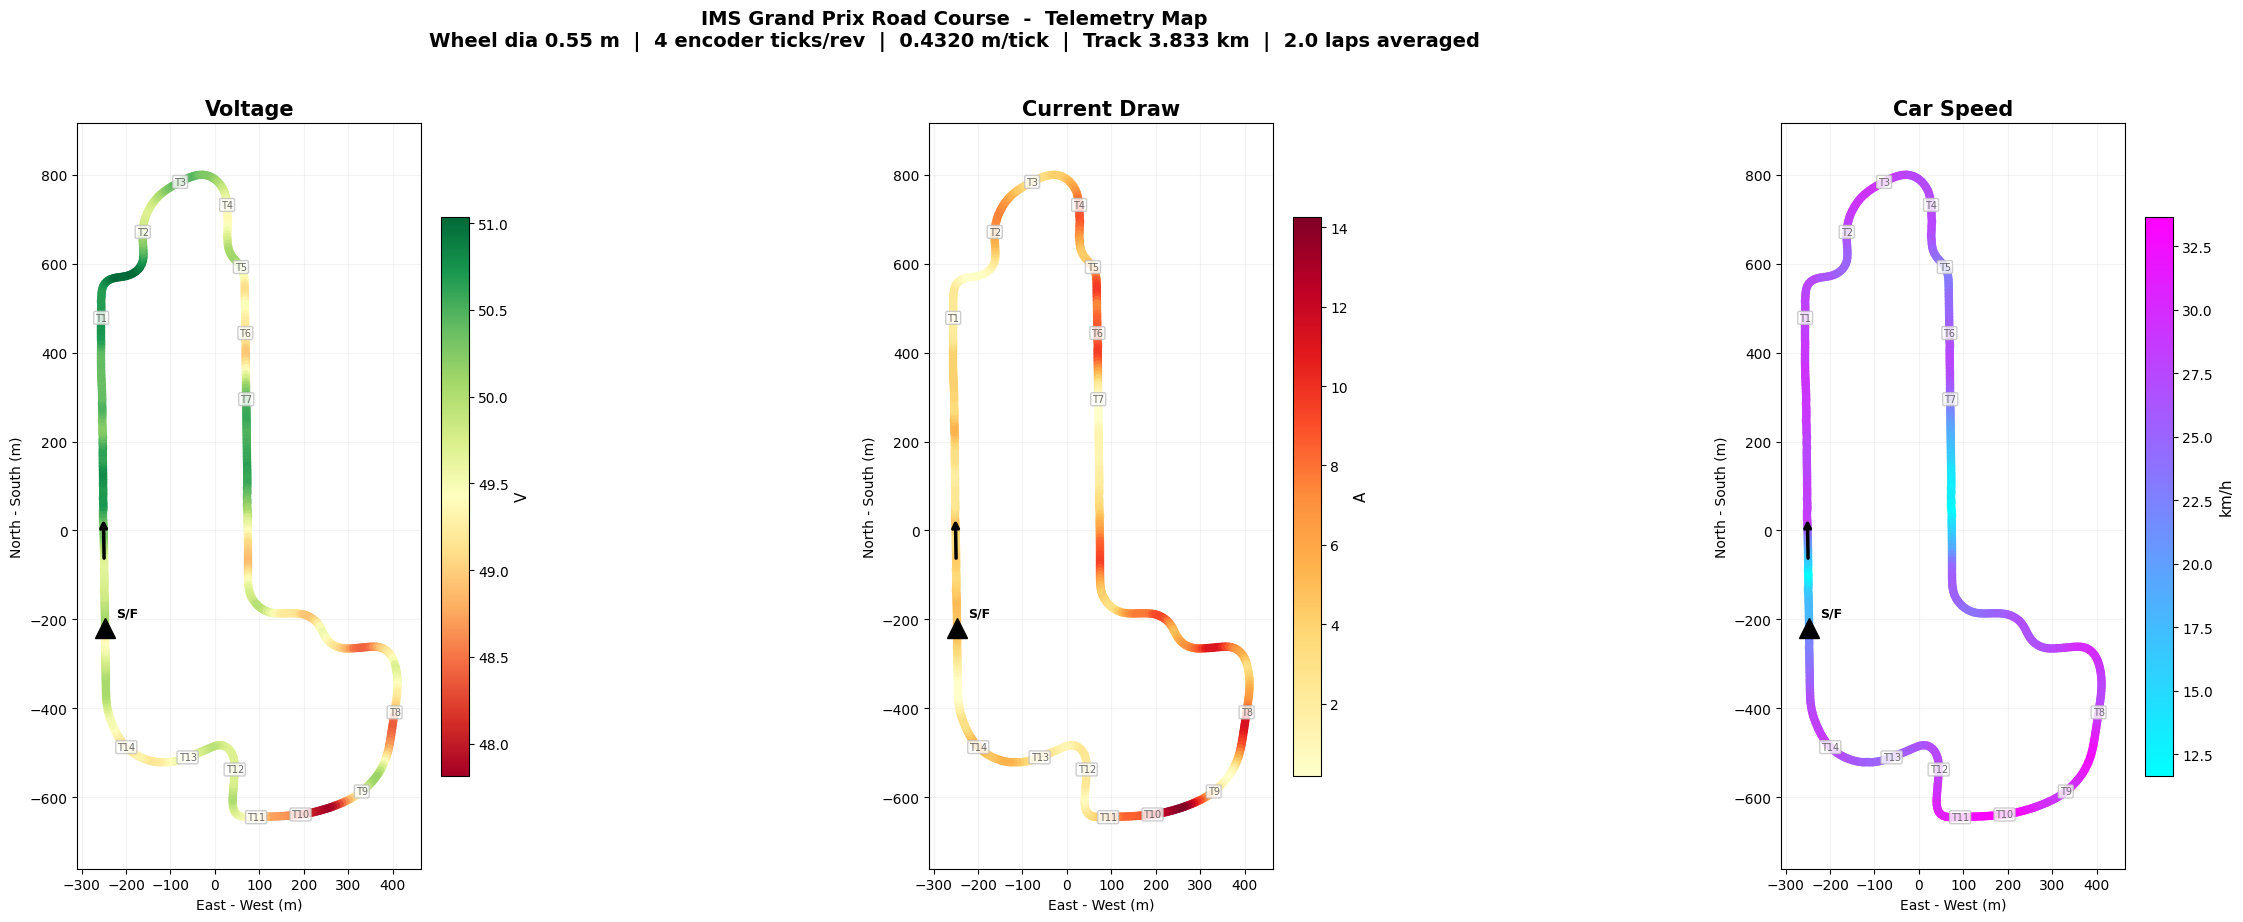

Saved: ims_telemetry_map.png


In [59]:
# ── Bin telemetry by track position (both laps averaged) ──
N_BINS = 500
bin_edges = np.linspace(0, TRACK_LEN, N_BINS + 1)
bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2

def bin_on_track(positions, values):
    """Average telemetry values into track-distance bins and smooth."""
    bin_idx = np.clip(np.digitize(positions, bin_edges) - 1, 0, N_BINS - 1)
    binned = pd.Series(values).groupby(bin_idx).mean().reindex(range(N_BINS))
    binned = binned.interpolate().bfill().ffill()
    # Light smoothing for cleaner visualization
    return binned.rolling(15, center=True, min_periods=1).mean().values

v_bin = bin_on_track(df['TrackPos'].values, df['Voltage_V'].values)
c_bin = bin_on_track(df['TrackPos'].values, df['Current_A'].values)
s_bin = bin_on_track(df['TrackPos'].values, df['Speed_kph'].values)

# Map bin centres to track XY coordinates
bin_xy = np.array([dist_to_xy(d) for d in bin_mids])
points = bin_xy.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Turn label positions (approximate track distance in metres)
turn_info = [
    ('T1',  700), ('T2',  950), ('T3', 1100), ('T4', 1250),
    ('T5', 1400), ('T6', 1550), ('T7', 1700),
    ('T8', 2650), ('T9', 2850), ('T10', 3000),
    ('T11', 3100), ('T12', 3250), ('T13', 3400), ('T14', 3550),
]

# ── Three-panel track map ──
fig, axes = plt.subplots(1, 3, figsize=(27, 9))

panels = [
    (v_bin, 'Voltage',      'V',    'RdYlGn'),
    (c_bin, 'Current Draw', 'A',    'YlOrRd'),
    (s_bin, 'Car Speed',    'km/h', 'cool'),
]

for ax, (vals, title, unit, cmap) in zip(axes, panels):
    norm = Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals))
    lc = LineCollection(segments, cmap=cmap, norm=norm,
                        linewidths=6, capstyle='round')
    lc.set_array(vals[:-1])
    ax.add_collection(lc)

    cbar = fig.colorbar(lc, ax=ax, shrink=0.75, pad=0.02)
    cbar.set_label(unit, fontsize=11)

    # Start / Finish marker
    sf = dist_to_xy(0)
    ax.plot(*sf, 'k^', ms=14, zorder=5)
    ax.annotate('S/F', sf, textcoords='offset points',
                xytext=(8, 8), fontsize=9, fontweight='bold')

    # Direction arrow on front straight
    a1, a2 = dist_to_xy(150), dist_to_xy(250)
    ax.annotate('', xy=a2, xytext=a1,
                arrowprops=dict(arrowstyle='->', color='black', lw=2.5))

    # Turn labels
    for lbl, d in turn_info:
        txy = dist_to_xy(d)
        ax.annotate(lbl, txy, fontsize=7, ha='center', va='center',
                    color='dimgray',
                    bbox=dict(boxstyle='round,pad=0.15',
                              fc='white', ec='silver', alpha=0.8))

    ax.set_aspect('equal')
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xlabel('East - West (m)')
    ax.set_ylabel('North - South (m)')
    ax.grid(True, alpha=0.15)
    ax.autoscale()
    ax.margins(0.08)

fig.suptitle(
    'IMS Grand Prix Road Course  -  Telemetry Map\n'
    f'Wheel dia {WHEEL_DIAM} m  |  {N_ENC} encoder ticks/rev  |  '
    f'{DIST_PER_TICK:.4f} m/tick  |  Track {TRACK_LEN/1000:.3f} km  |  '
    f'{n_laps:.1f} laps averaged',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('ims_telemetry_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ims_telemetry_map.png")

# Interactive Track Map — Per-Tick Slider
Drag the slider (or press play) to move the car around the real GPS track.  
Use the **Overlay** dropdown to switch the coloured metric behind the car.

In [60]:
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

# ── Load real GPS track ──
track_gps = pd.read_csv('sem-us-2022-track_coordinates.csv')
track_lat = track_gps.Latitude.values
track_lon = track_gps.Longitude.values

# Cumulative distance along GPS centreline (Haversine)
R_EARTH = 6_371_000  # metres
dlat = np.radians(np.diff(track_lat))
dlon = np.radians(np.diff(track_lon))
hav = (np.sin(dlat / 2) ** 2 +
       np.cos(np.radians(track_lat[:-1])) *
       np.cos(np.radians(track_lat[1:])) *
       np.sin(dlon / 2) ** 2)
track_arc = np.zeros(len(track_lat))
track_arc[1:] = np.cumsum(R_EARTH * 2 * np.arctan2(np.sqrt(hav), np.sqrt(1 - hav)))
GPS_LEN = track_arc[-1]

print(f"GPS track: {len(track_lat)} pts, {GPS_LEN:.0f} m")

# ── Map every telemetry sample → GPS position ──
gps_d   = (df['TrackPos'].values / TRACK_LEN) * GPS_LEN
gps_idx = np.clip(np.searchsorted(track_arc, gps_d), 0, len(track_lat) - 1)
car_lat = track_lat[gps_idx]
car_lon = track_lon[gps_idx]

# Map the 500 bins (from previous cell) → GPS for the coloured overlay
bin_gps_d   = (bin_mids / TRACK_LEN) * GPS_LEN
bin_gps_idx = np.clip(np.searchsorted(track_arc, bin_gps_d), 0, len(track_lat) - 1)
ov_lat = track_lat[bin_gps_idx]
ov_lon = track_lon[bin_gps_idx]

print(f"Mapped {len(car_lat)} telemetry samples to GPS coords")

GPS track: 3833 pts, 3833 m
Mapped 22353 telemetry samples to GPS coords


In [61]:
# ── Build plotly map + ipywidgets slider ──

fig = go.FigureWidget()

# Trace 0 — track outline (dark grey)
fig.add_trace(go.Scattermap(
    lat=track_lat, lon=track_lon,
    mode='lines',
    line=dict(color='#444', width=6),
    hoverinfo='skip', showlegend=False,
))

# Trace 1 — coloured metric overlay (dots along centreline)
fig.add_trace(go.Scattermap(
    lat=ov_lat, lon=ov_lon,
    mode='markers',
    marker=dict(
        size=6, color=s_bin,
        colorscale='Viridis',
        cmin=0, cmax=float(df['Speed_kph'].max()),
        showscale=True,
        colorbar=dict(title=dict(text='km/h'), x=1.0, len=0.5, y=0.75),
    ),
    hoverinfo='skip', showlegend=False,
))

# Trace 2 — car position (large red dot)
fig.add_trace(go.Scattermap(
    lat=[float(car_lat[0])], lon=[float(car_lon[0])],
    mode='markers',
    marker=dict(size=18, color='red'),
    showlegend=False,
))

fig.update_layout(
    map=dict(
        style='open-street-map',
        center=dict(lat=float(track_lat.mean()), lon=float(track_lon.mean())),
        zoom=14.5,
    ),
    margin=dict(l=0, r=0, t=0, b=0),
    height=600,
)

# ── Widgets ──
slider = widgets.IntSlider(
    value=0, min=0, max=len(df) - 1, step=1,
    description='Sample:',
    continuous_update=True,
    layout=widgets.Layout(width='85%'),
    style={'description_width': '55px'},
)

play_btn = widgets.Play(
    value=0, min=0, max=len(df) - 1, step=20,
    interval=30, description='Play',
)
widgets.jslink((play_btn, 'value'), (slider, 'value'))

metric_dd = widgets.Dropdown(
    options=['Speed', 'Current', 'Voltage'],
    value='Speed',
    description='Overlay:',
    style={'description_width': '55px'},
    layout=widgets.Layout(width='160px'),
)

info_html = widgets.HTML()

# Metric config:  (binned_values, colorscale, cmin, cmax, unit)
_metric_cfg = {
    'Speed':   (s_bin, 'Viridis', 0, float(df['Speed_kph'].max()), 'km/h'),
    'Current': (c_bin, 'YlOrRd',  0, float(df['Current_A'].max()),  'A'),
    'Voltage': (v_bin, 'RdYlGn',  float(df['Voltage_V'].min()),
                float(df['Voltage_V'].max()), 'V'),
}

def _on_metric(change):
    vals, cs, lo, hi, unit = _metric_cfg[change['new']]
    with fig.batch_update():
        fig.data[1].marker.color      = vals
        fig.data[1].marker.colorscale = cs
        fig.data[1].marker.cmin       = lo
        fig.data[1].marker.cmax       = hi
        fig.data[1].marker.colorbar.title.text = unit

metric_dd.observe(_on_metric, names='value')

def _on_tick(change):
    i = change['new']
    with fig.batch_update():
        fig.data[2].lat = [float(car_lat[i])]
        fig.data[2].lon = [float(car_lon[i])]

    spd  = df['Speed_kph'].iloc[i]
    volt = df['Voltage_V'].iloc[i]
    cur  = df['Current_A'].iloc[i]
    pwr  = volt * cur
    t_min = df['TimePlot'].iloc[i]
    dist  = df['Distance_m'].iloc[i]
    lap   = int(dist / TRACK_LEN) + 1
    thr   = df['Throttle'].iloc[i]

    info_html.value = (
        '<div style="font-family:\'Courier New\',monospace;font-size:15px;'
        'padding:12px;background:linear-gradient(135deg,#1a1a2e,#16213e);'
        'color:#eee;border-radius:10px;display:flex;gap:24px;flex-wrap:wrap;'
        'align-items:center;">'
        f'<div><span style="color:#888">TIME</span><br>'
        f'<b style="font-size:18px">{t_min:.2f} min</b></div>'
        f'<div><span style="color:#888">DISTANCE</span><br>'
        f'<b style="font-size:18px">{dist:.0f} m</b></div>'
        f'<div><span style="color:#888">LAP</span><br>'
        f'<b style="font-size:18px">{lap}</b></div>'
        '<div style="border-left:1px solid #444;padding-left:20px">'
        f'<span style="color:#4CAF50">VOLTAGE</span><br>'
        f'<b style="font-size:18px">{volt:.1f} V</b></div>'
        f'<div><span style="color:#FF9800">CURRENT</span><br>'
        f'<b style="font-size:18px">{cur:.1f} A</b></div>'
        f'<div><span style="color:#E91E63">POWER</span><br>'
        f'<b style="font-size:18px">{pwr:.1f} W</b></div>'
        '<div style="border-left:1px solid #444;padding-left:20px">'
        f'<span style="color:#2196F3">SPEED</span><br>'
        f'<b style="font-size:18px">{spd:.1f} km/h</b></div>'
        f'<div><span style="color:#9C27B0">THROTTLE</span><br>'
        f'<b style="font-size:18px">{thr}</b></div>'
        '</div>'
    )

slider.observe(_on_tick, names='value')
_on_tick({'new': 0})

# ── Assemble and display ──
controls = widgets.HBox(
    [play_btn, slider, metric_dd],
    layout=widgets.Layout(align_items='center', gap='8px'),
)
display(widgets.VBox([fig, controls, info_html]))

    'data': [{'hoverinfo': 'skip',
              'lat': {'bdata': ('mdTQBmDlQ0Dg…